# 01 · Exploración y discretización

**Proyecto:** Videojuegos y Rendimiento Académico — Ingeniería de Datos, UFRO.

**Dataset:** `Gaming_Academic_Performance.csv` (Kaggle, 8000 estudiantes): hábitos de juego, estudio, sueño y descanso, junto con la calificación final (`grades`, escala 0–100).

El objetivo final del proyecto es estimar la nota de un estudiante a partir de sus rutinas (regresión, eventualmente con una red neuronal). Esta entrega define un **problema de reglas de asociación** sobre el mismo dataset, como paso interpretable previo al modelado.

Este notebook prepara los datos para la minería de reglas (notebook `02_reglas_asociacion.ipynb`):

1. Perfilado del dataset crudo.
2. Limpieza de outliers en `grades` (notas > 100 y nota 0), **eliminando las filas** y conservando el dataset crudo intacto en `data/raw/` como respaldo.
3. Discretización de las variables numéricas por **cuartiles** (Q1–Q4), requisito para tratar cada variable como ítems categóricos en Apriori.
4. Guardado del dataset discretizado en `data/processed/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# raíz del repo: subir hasta el directorio que contiene data/ (funciona desde la raíz o desde cualquier subcarpeta de notebooks/)
REPO = Path.cwd().resolve()
while not (REPO / 'data').is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
RAW = REPO / 'data' / 'raw' / 'Gaming_Academic_Performance.csv'
PROCESSED = REPO / 'data' / 'processed' / 'dataset_discretizado.csv'

pd.set_option('display.max_columns', None)

df = pd.read_csv(RAW)
print('Dimensiones:', df.shape)
df.head()

Dimensiones: (8000, 14)


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


## Perfilado

Tipos, valores faltantes, duplicados y estadísticos básicos.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   str    
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   str    
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   str    
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), str(3)
memory usage: 875.1 KB


In [3]:
print('Nulos por columna:')
print(df.isna().sum())
print('\nFilas duplicadas:', df.duplicated().sum())
print('IDs de estudiante duplicados:', df['student_id'].duplicated().sum())

Nulos por columna:
student_id          0
age                 0
gender              0
gaming_hours        0
study_hours         0
sleep_hours         0
attendance          0
gaming_genre        0
social_activity     0
device_usage        0
reaction_time_ms    0
addiction_score     0
stress_level        0
grades              0
dtype: int64

Filas duplicadas: 0
IDs de estudiante duplicados: 0


In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
student_id,8000.0,4000.50,2309.55,1.00,2000.75,4000.50,6000.25,8000.00
age,8000.0,19.98,2.59,16.00,18.00,20.00,22.00,24.00
gaming_hours,8000.0,4.09,2.31,0.00,2.13,4.13,6.06,8.00
study_hours,8000.0,5.46,2.58,1.00,3.24,5.46,7.66,10.00
sleep_hours,8000.0,6.49,1.44,4.00,5.24,6.50,7.73,9.00
attendance,8000.0,79.89,11.58,60.00,69.78,79.69,90.10,100.00
social_activity,8000.0,2.51,1.44,0.00,1.29,2.50,3.76,5.00
device_usage,8000.0,7.59,2.71,1.10,5.56,7.61,9.60,13.95
reaction_time_ms,8000.0,271.11,29.44,183.26,247.16,270.48,294.69,347.87
addiction_score,8000.0,9.91,5.04,-4.51,5.92,10.00,13.86,23.16


### Distribuciones numéricas

Las variables de hábitos (`gaming_hours`, `study_hours`, etc.) muestran distribuciones aproximadamente **uniformes** — consistente con un dataset sintético. `grades` es la excepción: asimétrica hacia la izquierda y con un máximo que supera la escala (> 100), lo que se trata en la sección de limpieza.

Otro detalle sintético: `addiction_score` registra valores **negativos** (mín −4.51), algo sin sentido para un puntaje de adicción; lo interpretamos como ruido del generador y no lo tratamos aparte (la discretización por cuartiles lo absorbe en Q1).

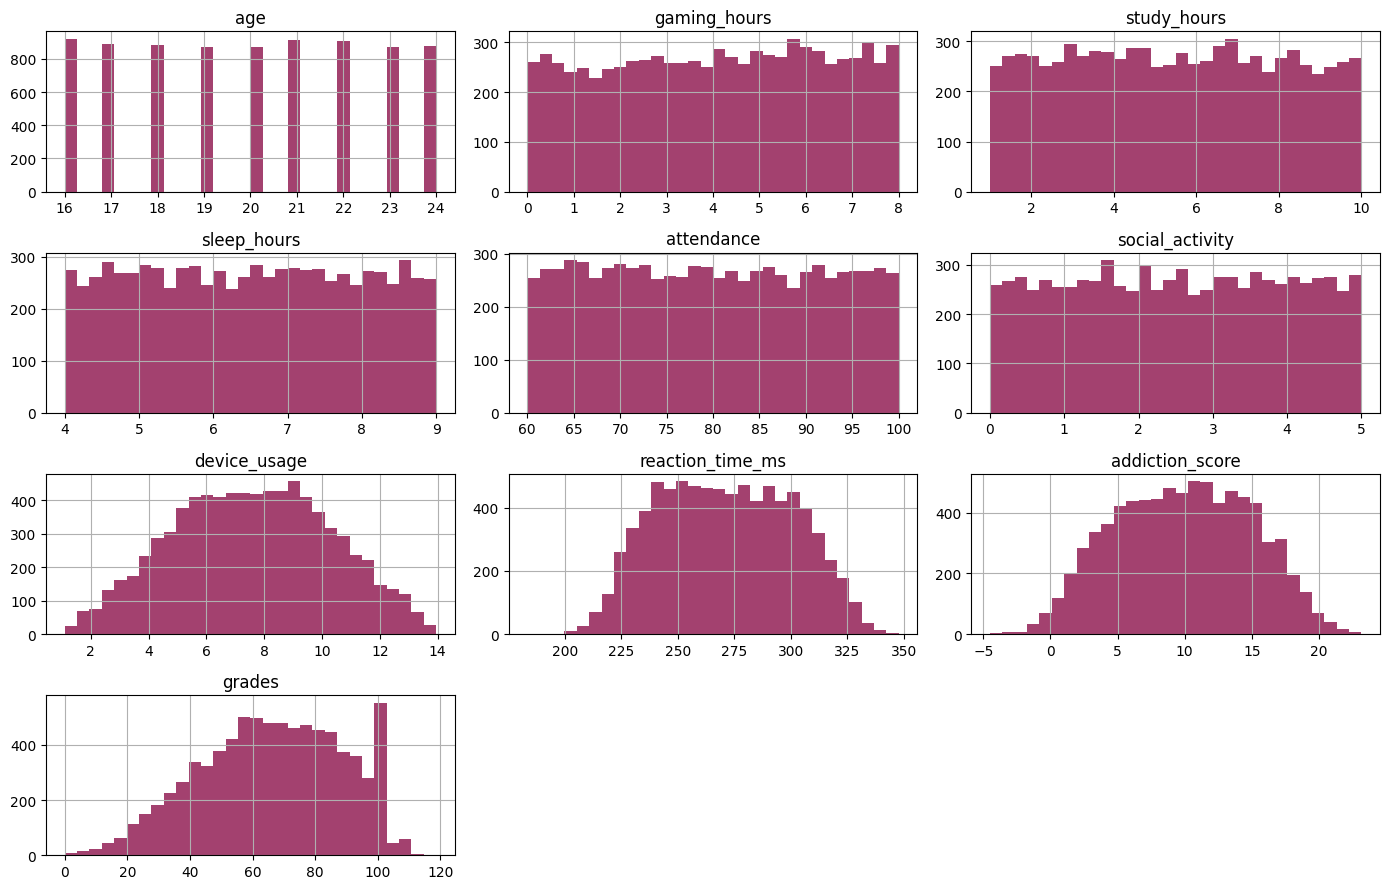

In [5]:
num_cols = ['age', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance',
            'social_activity', 'device_usage', 'reaction_time_ms', 'addiction_score', 'grades']

df[num_cols].hist(bins=30, figsize=(14, 9), color='#a3416f')
plt.tight_layout()
plt.show()

### Variables categóricas

`gender`, `gaming_genre` y `stress_level` ya son categóricas: entran a la minería de reglas tal cual, sin discretizar.

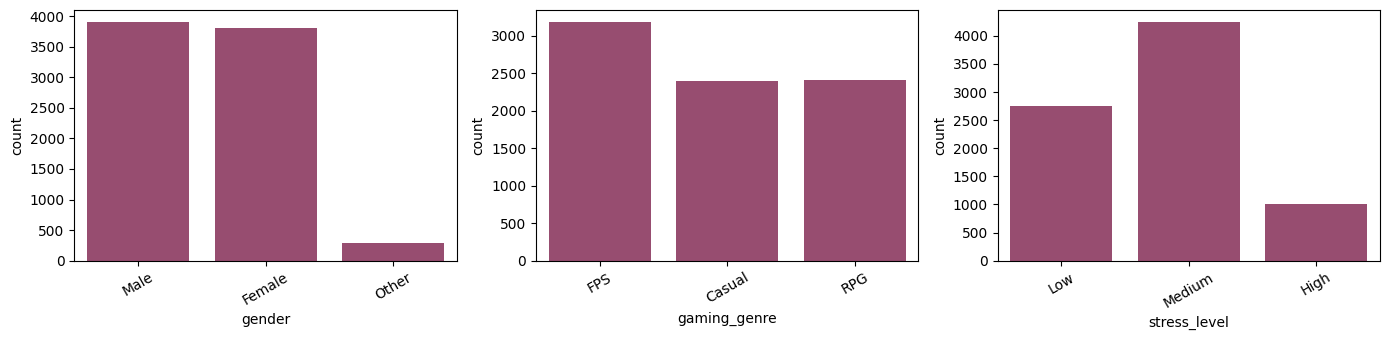

gender
Male      3904
Female    3803
Other      293
Name: count, dtype: int64 

gaming_genre
FPS       3187
RPG       2408
Casual    2405
Name: count, dtype: int64 

stress_level
Medium    4247
Low       2743
High      1010
Name: count, dtype: int64 



In [6]:
cat_cols = ['gender', 'gaming_genre', 'stress_level']

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, c in zip(axes, cat_cols):
    sns.countplot(data=df, x=c, ax=ax, color='#a3416f')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

for c in cat_cols:
    print(df[c].value_counts(), '\n')

## Limpieza: outliers en `grades`

En la exploración previa del equipo se detectaron **calificaciones sobre 100** (fuera de escala) y **una nota 0** (posible abandono o nulo disfrazado).

**Decisión:** eliminar esas filas. Son pocas respecto al total y su origen es dudoso; mantenerlas distorsionaría los cuartiles de `grades`. El dataset crudo queda intacto en `data/raw/` como respaldo, de modo que la decisión es reversible.

In [7]:
n_sobre_100 = (df['grades'] > 100).sum()
n_cero = (df['grades'] == 0).sum()
print(f'Notas > 100: {n_sobre_100} (máx {df["grades"].max():.2f})')
print(f'Notas == 0: {n_cero}')

df_limpio = df[(df['grades'] <= 100) & (df['grades'] > 0)].copy()
print(f'Filas: {len(df)} -> {len(df_limpio)} (eliminadas: {len(df) - len(df_limpio)})')

Notas > 100: 134 (máx 118.63)
Notas == 0: 1
Filas: 8000 -> 7865 (eliminadas: 135)


## Discretización por cuartiles

Apriori trabaja sobre ítems categóricos, así que cada variable numérica se transforma en 4 niveles ordenados **Q1 < Q2 < Q3 < Q4** usando sus cuartiles (`pd.qcut`). Con distribuciones casi uniformes, esto produce bins balanceados (~25% de las filas cada uno), lo que evita ítems con soporte desproporcionado.

- `student_id` se descarta: es identificador, no atributo.
- Las categóricas (`gender`, `gaming_genre`, `stress_level`) se mantienen tal cual.

La tabla de rangos por cuartil sirve para leer las reglas del notebook 02 (ej.: saber qué horas concretas significa `gaming_hours=Q4`).

In [8]:
etiquetas = ['Q1', 'Q2', 'Q3', 'Q4']

df_disc = df_limpio[cat_cols].copy()
cortes = {}
for c in num_cols:
    serie, bins = pd.qcut(df_limpio[c], q=4, retbins=True, duplicates='drop')
    df_disc[c] = serie.cat.rename_categories(etiquetas[:len(bins) - 1])
    cortes[c] = bins

rangos = pd.DataFrame({
    c: {f'Q{i + 1}': f'({cortes[c][i]:.2f}, {cortes[c][i + 1]:.2f}]' for i in range(len(cortes[c]) - 1)}
    for c in num_cols
}).T
rangos

,Q1,Q2,Q3,Q4
age,"(16.00, 18.00]","(18.00, 20.00]","(20.00, 22.00]","(22.00, 24.00]"
gaming_hours,"(0.00, 2.17]","(2.17, 4.17]","(4.17, 6.08]","(6.08, 8.00]"
study_hours,"(1.00, 3.19]","(3.19, 5.38]","(5.38, 7.56]","(7.56, 10.00]"
sleep_hours,"(4.00, 5.23]","(5.23, 6.48]","(6.48, 7.71]","(7.71, 9.00]"
attendance,"(60.00, 69.73]","(69.73, 79.56]","(79.56, 89.99]","(89.99, 100.00]"
social_activity,"(0.00, 1.28]","(1.28, 2.50]","(2.50, 3.76]","(3.76, 5.00]"
device_usage,"(1.10, 5.59]","(5.59, 7.64]","(7.64, 9.61]","(9.61, 13.95]"
reaction_time_ms,"(183.26, 246.87]","(246.87, 270.14]","(270.14, 294.31]","(294.31, 347.87]"
addiction_score,"(-4.51, 5.99]","(5.99, 10.07]","(10.07, 13.90]","(13.90, 23.16]"
grades,"(0.04, 49.51]","(49.51, 66.54]","(66.54, 83.21]","(83.21, 100.00]"


In [9]:
# proporción de filas por cuartil: debe rondar 0.25 en cada bin
pd.DataFrame({c: df_disc[c].value_counts(normalize=True).sort_index().round(3) for c in num_cols}).T

,Q1,Q2,Q3,Q4
age,0.336,0.218,0.227,0.219
gaming_hours,0.251,0.249,0.249,0.250
study_hours,0.250,0.251,0.249,0.250
sleep_hours,0.252,0.249,0.250,0.249
attendance,0.250,0.250,0.250,0.250
social_activity,0.250,0.251,0.250,0.249
device_usage,0.251,0.250,0.249,0.250
reaction_time_ms,0.250,0.250,0.250,0.250
addiction_score,0.250,0.250,0.250,0.250
grades,0.250,0.250,0.250,0.250


In [10]:
PROCESSED.parent.mkdir(parents=True, exist_ok=True)
df_disc.to_csv(PROCESSED, index=False)
print('Guardado:', PROCESSED, '| dimensiones:', df_disc.shape)
df_disc.head()

Guardado: /home/strawberry/Projects/Gaming-vs-Academic/data/processed/dataset_discretizado.csv | dimensiones: (7865, 13)


,gender,gaming_genre,stress_level,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
0,Male,FPS,Low,Q3,Q4,Q4,Q3,Q4,Q3,Q3,Q1,Q4,Q4
1,Male,Casual,Medium,Q2,Q1,Q4,Q3,Q1,Q1,Q1,Q4,Q1,Q4
2,Female,Casual,High,Q4,Q1,Q4,Q1,Q3,Q3,Q1,Q4,Q1,Q4
3,Female,RPG,Low,Q2,Q4,Q1,Q4,Q2,Q2,Q4,Q1,Q4,Q1
4,Female,FPS,Low,Q3,Q3,Q3,Q2,Q1,Q1,Q3,Q2,Q3,Q2


## Resumen

- Dataset crudo: 8000 filas, sin nulos ni duplicados.
- Limpieza: se eliminaron 135 filas (134 con `grades > 100`, 1 con `grades == 0`) → 7865 filas; el crudo queda como respaldo en `data/raw/`.
- Las 10 variables numéricas quedaron discretizadas en cuartiles Q1–Q4 con bins balanceados (~25% cada uno). Única excepción: `age`, que por ser entera queda con cortes desiguales (Q1 ≈ 34%) — aceptable, no es variable central del análisis.
- Las 3 categóricas (`gender`, `gaming_genre`, `stress_level`) se conservan tal cual.
- Salida: `data/processed/dataset_discretizado.csv` (7865 × 13), insumo del notebook `02_reglas_asociacion.ipynb`.